# Do Discounts Affect Customer Ratings?

This notebook investigates whether product discounts have a measurable effect on customer satisfaction. The analysis uses a Brazilian ecommerce public dataset of orders made at Olist Store. The dataset has information of 100k orders from 2016 to 2018 made at multiple marketplaces in Brazil.

A power analysis will be performed to determine the appropiate sample size and a stratified random sample will be drawn from the data to ensure the test is calibrated to detect practically meaningful differences rather than inflating significance through use of the full order dataset.

The analysis is done with a primary test in mind with 2 sensitivity analysis to supplement: 
1. Discounted vs Full-Price orders effect on customer ratings. (PRIMARY)
2. Does the magnitude of the discount influence effect size? (SENSITIVITY)
3. Does the effect persist when holding other variables constant? (SENSITIVITY)

**Experiment Design & Observational Analysis**  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Author:** Joe Laniado  
**Date:** June 2026

## 1. Executive Summary

## 2.Business Problem & Experiment Context

### 2.1 Business Motivation
Discounts and promotions are among the most widely used tools in e-commerce. The whole concept stems from the assumption that a product's perceived value is anchored to its original price, so when a discount is applied, the customer believes they are obtaining that same value at a lower cost, creating a sense of opportunity.

This raises an interesting question about customer psychology: **If a customer pays less than the listed price, does that alter how they evaluate the product after purchase?**

Two competing effects are plausible:
- **Leniency**: customers who received a discount may feel they got a good deal and be more lenient when rating the product, regardless of the product's actual quality.
- **Quality perception**:  a heavily discounted product may signal low demand or poor quality to the customer before purchase, priming them to evaluate it more critically upon receipt.

If either effect is present and measurable, it has direct implications for how businesses develop their pricing strategies. **What if chasing short-term sales volume through discounting risks long-term damage to customer satisfaction?**


### 2.2 Research Question

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>Are discounted purchases associated with diffferent customer ratings than purchases made at or near their historical reference price?</b>
</div>


### 2.3 Experimental vs Observational Setting
It is important to make the distinction that we are dealing with historical data that has already been observed and is not randomized for the purpose of an experiment. Therefore, the historical analysis can estimate associations between discount status and customer ratings, but it cannot establish that discounts causally change ratings.

Section 5 presents how the same business question could be tested causally using a prospective randomized A/B experiment.

### 2.4 Scope of Analysis
The scope of our analysis is limited to the following:

- Brazil e-commerce retail platform Olist.
- For the period of August 1, 2017 - July 31, 2018.
- Single Item, completed purchases.
- For seller-product pairs with at least three prior price observations.
- Purchases that received a customer rating.

It is important to not generalise the results of the analysis outside this scope as other markets might behave differently than this one.

## 3. Hypothesis & Statistical Framework

### 3.1 Primary Hypothesis
**Primary Test. Discount vs Non-Discounted Orders.**

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H<sub>0</sub>:</b> After adjusting for seller-product and time effects, discounted purchases are not associated with a difference in means for customer rating relative to non-discounted purchases. ($\mathbf{\beta}$$= 0$)<br><br>
<b>H<sub>1</sub>:</b> After adjusting for seller-product and time effects, discounted purchases are associated with a difference in means for customer rating relative to non-discounted purchases. ($\mathbf{\beta}$ $\neq 0$)
</div>

### 3.2 Primary Outcome Metric

**Customer rating** (1-5): The review score submitted by the customer on a 1-5 scale after making a single item purchase. Where multiple reviews exist for one order, the earliest review is retained. To maintain one observation per customer, only each customer's first eligible delivered order within the analysis window is retained.

### 3.3 Treatment & Control Groups
- **Control:** Orders priced less than 1% below their seller-product prior maximum observed price. It represents orders near or equal their historical reference price.
- **Treatment:** Orders priced at least 1% below their seller-product prior maximum observed price. It represents orders with an inferred discount from their historical reference price.

### 3.4 Primary Estimand
The primary estimand is the adjusted mean difference in customer rating associated with discounted versus non-discounted purchases within the eligible analytical population.

An absolute difference of 0.3 rating points is pre-specified as the smallest effect considered practically meaningful.


### 3.5 Statistical Parameters
The statistical parameters for each section of our analysis is as follows:

**Historical Observational Analysis**:
- Significance level: $\alpha$ = 0.05
- Practical absolute difference threshold: $|\Delta|$ = 0.3 rating points.

**Prospective A/B Test design**
- $\alpha$ = 0.05
- *Power* = 0.8
- *MDE* = 0.3 rating points

### 3.6 Analysis Hierarchy
The analysis hierarchy follows a 4 step approach:
- **Primary Test**: A fixed-effects linear regression estimating the adjusted association between discount status and mean customer rating, accounting for seller-product and time effects.
- **Sensitivity**: A Mann-Whitney U test provides an unadjusted rank based comparison of customer ratings between discounted and non-discounted purchases, addressing the ordinal and skewed distribution. The effect size is calculated using rank-biserial correlation.
- **Exploratory**: A dose-response analysis uses Kruskal-Wallis to test whether rating distributions differ across discount depth groups. The effect size is calculated using epsilon squared.
- **Experiment Design**: A prospective randomized A/B test design demonstrates randomization, sample size planning, Type I error, statistical power, and the operating characteristics of the proposed experiment.

## 4. Historical Data

### 4.1 Data Overview

The raw historical data is sourced from a Brazilian ecommerce public dataset of orders made at Olist Store between 2016 and 2018. The entire history is loaded into a duckdb database and run through a pre-processing pipeline using SQL to prepare for the analysis. The complete ETL process can be found at **ETL.ipynb**.

The clean analytical table contains 31,625 rows presented at the order level made for the period of **August 1, 2017 - July 31, 2018**.  Each order corresponds to a unique customer, has only one review, one product, and a seller-product pairs with at least three prior price observations. 


In [1]:
import numpy as np
import pandas as pd
np.random.seed(42)

# Loading the data.
path = "data/clean_sales_data.csv"
df = pd.read_csv(path)

# Modify data type of date variable.
df = df.astype({'order_purchase_timestamp':'datetime64[ns]'})

# Output 
print(df.info(),
    f"\n\nTotal rows: {len(df):,}\n"
    f"Unique orders: {df['order_id'].nunique():,}\n"
    f"Unique customers: {df['customer_unique_id'].nunique():,}"
)

<class 'pandas.DataFrame'>
RangeIndex: 31625 entries, 0 to 31624
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  31625 non-null  str           
 1   customer_unique_id        31625 non-null  str           
 2   customer_state            31625 non-null  str           
 3   order_purchase_timestamp  31625 non-null  datetime64[ns]
 4   customer_rating           31625 non-null  int64         
 5   product_id                31625 non-null  str           
 6   seller_id                 31625 non-null  str           
 7   price                     31625 non-null  float64       
 8   freight_value             31625 non-null  float64       
 9   product_category          31625 non-null  str           
 10  prior_max_price           31625 non-null  float64       
 11  n_prior_price_obs         31625 non-null  int64         
 12  discount_ptg              316

The clean data has no missing values and the total number of rows is equal to unique orders.

### 4.2 Group Distribution
There is an imbalanced number of discounted orders compared to non-discounted. The distribution between our control and treatment group can be seen below:

In [2]:
# Separate discounted orders.
df['discounted'] = np.where(df['discount_ptg']>=1, 1, 0)

control, treatment = df[df['discounted']==0], df[df['discounted']==1]

print(f"Total orders in dataset: {len(df)}\n"
      f"Orders in Control: {len(control)}\n"
      f"Orders in Treatment: {len(treatment)}")

Total orders in dataset: 31625
Orders in Control: 21363
Orders in Treatment: 10262


The analytical cohort contains 21,363 non-discounted orders (67.5%) and 10,262 discounted orders (32.5%). Although the groups are unequal in size, both contain substantial numbers of observations, so no artificial balancing or downsampling is required.

### 4.3 Primary Metric Distribution
Ratings are strongly concentrated at five stars, producing a negatively skewed distribution.  We visualize the distribution of our variable and separate it by their assigned group below:

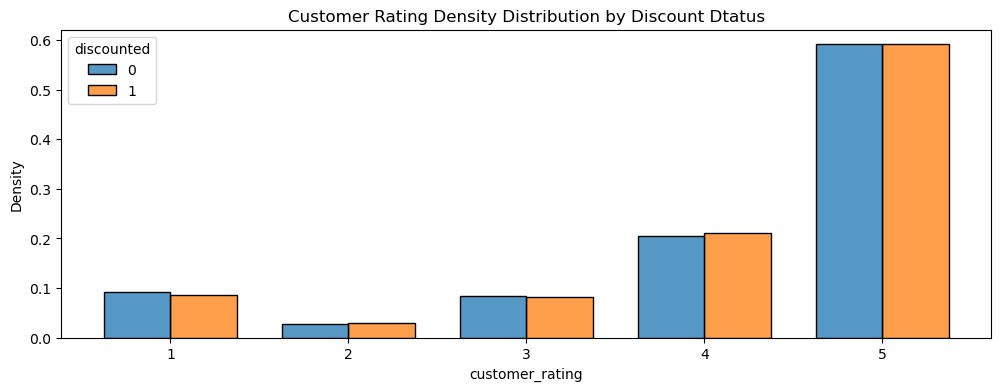

Mean and standard deviation for our analytical dataset:
Population mean = 4.18, sd = 1.25
Control mean = 4.18, sd = 1.26
Treatment mean = 4.19, sd = 1.24



In [4]:
# Vizualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Customer_rating visualization.
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(data=df,x='customer_rating',
             hue='discounted',
             discrete=True,
             ax=ax,
             multiple='dodge',
             shrink=0.75,
             stat='density',
             common_norm=False)
ax.set_title("Customer Rating Density Distribution by Discount Dtatus")
plt.show()

pop_mean, pop_sd = df['customer_rating'].mean(), df['customer_rating'].std()
control_mean, treatment_mean = control['customer_rating'].mean(), treatment['customer_rating'].mean()
control_sd, treatment_sd = control['customer_rating'].std(), treatment['customer_rating'].std()

print(f"Mean and standard deviation for our analytical dataset:\n"
      f"Population mean = {pop_mean:.2f}, sd = {pop_sd:.2f}\n"
      f"Control mean = {control_mean:.2f}, sd = {control_sd:.2f}\n"
      f"Treatment mean = {treatment_mean:.2f}, sd = {treatment_sd:.2f}\n")

The raw mean ratings are nearly identical between groups: 4.18 for non-discounted orders and 4.19 for discounted orders. This comparison is descriptive and unadjusted, so no inferential conclusion is drawn at this stage.

### 4.4 Treatment Variable
The original dataset does not contain an explicit discount indicator, so it had to be engineered from the raw dataset. **Discount_ptg** was calculated usign the following formula:

$$\text{Discount \%(t)} = \left(\frac{P_{max\_prior} - P_{t}}{P_{max\_prior}}\right) \times 100$$

where Pmax_prior represents the seller-product's prior maximum observed price.

This proxy requires sufficient historical pricing information. Orders with fewer than three prior seller-product price observations are therefore excluded from the analytical cohort rather than automatically classified as non-discounted.

The distribution for **discount_ptg** can be seen below:

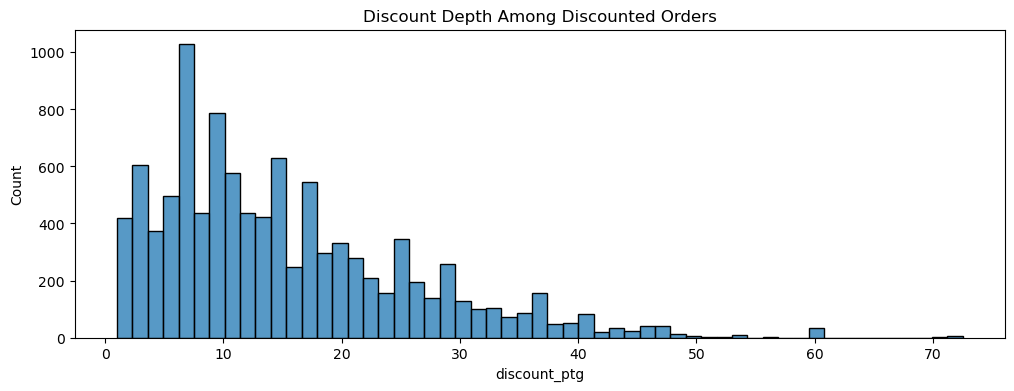

In [5]:
# Discount_ptg
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(data=df[df['discounted']==True],
             x='discount_ptg',
             ax=ax,
             )
ax.set_title("Discount Depth Among Discounted Orders")
plt.show()

Most discounts seem to fall on the low to medium range, with only a few on the deeper end. 

### 4.5 Discounts Over Time

We explore discounting over time by plotting the percentage of orders with a discount by month throughout the year. This helps us identify any effect that time and seasonality could have in our results.

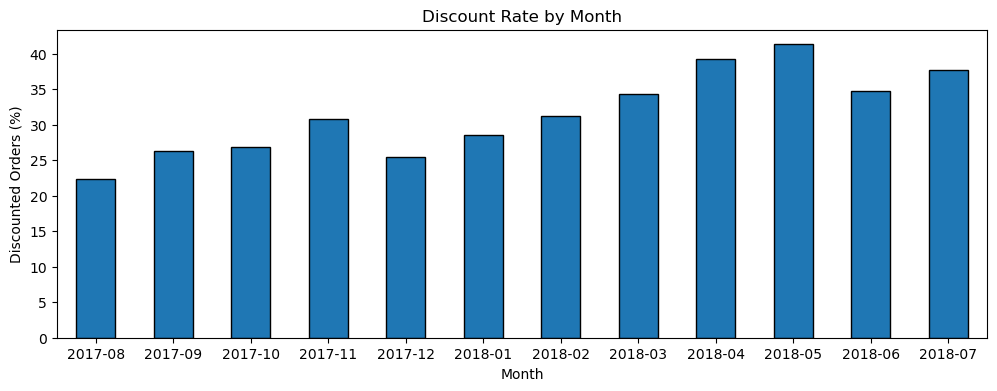

In [6]:
df["month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Plot discount variation by month
fig, ax = plt.subplots(figsize=(12, 4))

monthly_discount = (
    df.groupby("month")["discounted"]
      .mean()
      .mul(100)).plot(kind='bar', ax=ax, edgecolor='black')

ax.set_title('Discount Rate by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Discounted Orders (%)')
plt.xticks(rotation=0, ha='center')
plt.show()

The percentage of discount orders seem to lean towards more discounts in the spring and summer while tapering down during fall and winter. This temporal variation supports the inclusion of month fixed effects in the primary adjusted model.

### 4.6 Seller-Product Treatment Variation

Because the primary fixed-effects model relies on within seller-product variation in discount status, we examine how many seller-product pairs are observed under both discounted and non-discounted conditions.

In [7]:
# Create seller-product variable
df["seller_product_id"] = (df["seller_id"] + "_" + df["product_id"])

# Calculate the treatment variation by seller-product
pair_variation = df.groupby("seller_product_id")["discounted"].agg(["count", "nunique", "mean"])
number_pairs = len(pair_variation)

# Calculate distribution of pairs by group
only_control = ((pair_variation['nunique'] == 1) & (pair_variation['mean']==0)).sum()
only_treatment = ((pair_variation['nunique'] == 1) & (pair_variation['mean']==1)).sum()
both = (pair_variation['nunique']==2).sum()

mixed_ids = pair_variation.query("nunique == 2").index

n_obs_mixed = df["seller_product_id"].isin(mixed_ids).sum()

print(f"Out of a {number_pairs} unique seller-product pairs:\n\n"
    f"{only_control} appear only in the control group\n"
    f"{only_treatment} appear only in the treatment group\n"
    f"{both} appear in both\n\n"
    f"{n_obs_mixed}/{len(df)} of our observations have a seller-product pair that appears in both groups.")


Out of a 4811 unique seller-product pairs:

3478 appear only in the control group
739 appear only in the treatment group
594 appear in both

10852/31625 of our observations have a seller-product pair that appears in both groups.


Of the 4,811 unique seller-product pairs, 594 (12.3%) appear under both discounted and non-discounted conditions. These mixed pairs account for 10,852 orders (34.3% of the analytical dataset). Because seller-product fixed effects estimate the discount association using within-pair variation, these observations provide the primary identifying variation for the adjusted model. The number of mixed pairs and observations indicates that a within seller-product analysis is feasible.

## 5. Prospective A/B Test Design
A future randomized experiment could be designed using the following framework if given the opportunity for Olist in the future.

### 5.1 Experiment Design
The experimental unit would be the **customer**, and our group definition would be similar to the one from our observational analysis:
- **Control**: Customers presented with items without a discount.
- **Treatment**: Customers that are assigned a discount offer.
  
The discount offer would have a 50/50 random assignment.


### 5.2 Statistical Design
As mentioned in section 3.5 our experiment would be done with the following parameters:
- $\alpha$ = 0.05
- *Power* = 0.8
- *MDE* = 0.3 rating points

With this parameters and the standard deviation of past observed customer ratings as a reference we perform a power analysis to get our neccerary sample size for each group.

In [28]:
from statsmodels.stats.power import TTestIndPower
# Experiment key components
significance = 0.05
power = 0.8
mde = 0.3

cohens_d = mde / pop_sd

# Declare power analysis 
analysis = TTestIndPower()
sample_size = int(np.ceil(analysis.solve_power(effect_size=cohens_d, alpha=significance, power=power)))

print(f'The minimum number of samples per group to spot a real effect given our parameters is: {sample_size}')

The minimum number of samples per group to spot a real effect given our parameters is: 274


So we would need to collect 274 order reviews both for the control and treatment group in this case.

### 5.3 Experiment Validity & Stopping rules

### 5.4 Simulation

### 5.5 Power Curve

## 6. Primary Historical Analysis

### 1.2 Hypotheses
A hypothesis will be defined for each of the stages of analysis. 

**Primary Test. Binary A/B test: Discount vs Full Price Orders.**

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H<sub>0</sub>:</b> There is no difference in the distribution of customer ratings between the two groups.<br><br>
<b>H<sub>1</sub>:</b> The distribution of customer ratings is different between discount and full price orders.
</div>

A two tailed test will be used, as we dont know the direction of effect if any.

**Analysis 2. Dose response analysis: Discount depth buckets.**

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H<sub>0</sub>:</b> The distribution of customer satisfaction ratings is equal across all discount depth buckets.<br><br>
<b>H<sub>1</sub>:</b> At least one discount depth bucket has a different distribution in customer ratings compared to the others.
</div>

It is important to note that the second test will be performed regardless of the outcome of stage 1. Some effects may only be detected at deeper discount levels than if looking at the whole data.

**Analysis 3. Regression analysis: keeping all other variables constant is there still an effect?**

<div style="background-color:#f0f4fb; padding:12px; 
border-left:4px solid #2d4a7a; border-radius:4px; margin:8px 0">
<b>H<sub>0</sub>:</b> After controlling for all other variables discount percentage has no effect on customer rating<br><br>
<b>H<sub>1</sub>:</b> After controlling for all other variables discount percentage has a significant effect on customer rating
</div>



This will help us account for possible confounding variables that could mask the true effect of discount variables in customer ratings.

### 1.3 Experiment design
**Data**

The Data is presented at the order level. Each order corresponds to a unique customer, has only one review, one item, and has been delivered within the estimated time provided to the customer.

The processed dataset contains 99,441 raw orders reduced to 63,084 analytical rows made from **Aug 2017 - Aug 2018**. The one year period was chosen to capture seasonality and simulate limited data availability. The full ETL pipeline can be seen in the notebook **ETL.ipynb**. 

Our main variables consist of:
- **customer_rating** (Overrall Evaluation Criterion): 1-5 review for the product purchased for an individual order.
- **discount_ptg** (Main Treatment Variable): Represents the discount made in an order for a single product.
- **n_price_obs** (Sensitivity Variable): Represents the number of times a seller, product combination appears per order.
- **price** (Regression Confounding): product tier may independently affect satisfaction
- **freight_value** (Regression Confounding): shipping burden may affect satisfaction independently of the product
- **payment_installments** (Regression Confounding): May differ between discount groups.
- **product_category** (Regression Confounding): categories have different baseline rating levels
- **customer_state** (Regression Confounding): regional differences in rating behaviour

**OEC Metric**

Customer rating: The first review score submitted by the customer on a 1-5 scale. Where multiple reviews exist for one order the earliest by submission date is used, capturing the customer's initial unfiltered reaction to the purchase experience. If a customer had made multiple orders, only their first order is kept in the dataset to maintain independence.

**Treatment Variable**

The original data lacked a discount variable for each order, so it had to be engineered from the raw dataset. We calculated it by using the following formula:

$$\text{discount %} = \left(\frac{P_{max} - P_{actual}}{P_{max}}\right) \times 100$$

where Pmax is the maximum historical price listed for an item at the seller-product level. 

This approach assumes that any price variation from the max is considered a discount. It also introduces bias when sampling into groups as seller-product pairs that only appear once will be moved into the control group. The **n_price_obs** variables was build to reduce this bias by having the ability to filter for pairs that appear more than once in our experiment if needed.


**Groups**
- **Control:** Orders where discount_ptg < 1. The product was sold at its maximum historical price for that seller/product pair.
- **Treatment:** Orders where discount_ptg >= 1. The product was sold below its maximum historical price, implying a discount was applied.

**Sample size & Significance**

The experiment assumes the following parameters:
- *alpha* = 0.05
- *MDE* = 0.3
- *Power* = 0.8

A 0.3 change in customer rating is chosen to evaluate if there is a significant effect. A power analysis will be used to determine the appropiate sample size for statistical rigor in our primary test and a second sample will be drawn using n_price_obs > 3 to confirm results. If more data is needed for analyses 2 and 3 it will be collected from the main population to complement the original sample. 

**Statistical Hierarchy**

Analysis 1 is the Primary test. Analysises 2 and 3 cannot override the results and serve only as sensitivity analysis that supplement the primary findings. All results will be reported regardless of outcome.

**Analysis 1**

Due to the skewed, and ordinal nature of customer ratings a two tailed **Mann-Whitney U** will be used in our primary analysis. The non-parametric ranking approach will fit the nature of customer ratings better than a standard independent samples t-test. It will compare the distribution in rankings of the two groups and determine if there is a significant difference.

Due to the nature of **discount_ptg** and how it's calculated, a second sample will be drawn where the number of seller-product pairs in orders appear at least 3 times to validate results and reduce bias from the way our treatment metric is calculated.

The effect size will be determined using the rank-biserial correlation (r) between the two groups. It shows how much more likely it is for one group to outrank the other. It is bounded between [-1,1] with a stronger effect closer to -1 or 1, and no effect at 0.

**Analysis 2**

A Kruskal-Wallis test and a subsequent Dunn's post hoc test with bonferroni correction will be performed on the distribution of customer ratings grouped by different levels of discount:
- 0% No discount
- 1-10% Low discount
- 11-25% Medium discount
- 26-40% High discount
- 40%+ Very High discount

This serves as a dose-response analysis to determine whether the level of discount affects customer ratings.

Kruskal-Wallis determines whether a significant difference exists across groups. Dunn's post-hoc test with Bonferroni correction then identifies which specific bucket pairs drive that difference.

For this analysis effect size will be measured using $\epsilon^2$. It measures how much variation in customer rating is explained by what discount bucket an order is assigned to. A smaller value correlates to a small effect.

**Analysis 3**

A OLS Regression analysis will be run to evaluate the effect of discount_ptg on customer rating keeping all other variables constant. We do this to account for possible confounding variables not detected on the other experiments. The regression formula is as follows: 

$$\text{customer\_rating} = \beta_0 + \beta_1(\text{discount\_ptg}) + \beta_2(\text{freight\_value}) + \beta_3(\text{payment\_installments}) + \beta_4(\text{price}) + \beta_k(\text{product\_category}) + \beta_j(\text{customer\_state}) + \varepsilon$$

The output of this sensitivity analysis will provide:
- F-statistic: if the model itself is statistically significant.
- discount_ptg coefficient: the effect that a 1% increase in discount_ptg has on customer rate keeping all variables constant.
- discount_ptg p-value: if the effect of discount in customer ratings is statistically significant.
- R2 and Adj R2: How much of the variation in customer ratings can be explained by our model.

**Limitations**

A couple limitations for our experiment can be noted below:
- The analysis is performed on observational data rather than data collected through a controlled experiment. This causes that no random assignment can be performed for our treatment. Observed discounts could be driven by other confounding variables that could bias the result. The third analysis hopes to diminish these effects, but it is important to note that findings describe associations rather than causal relationships.
- The discount variable is engineered rather than observed directly. The assumption that the maximum historical price represents the true list price may not always hold.
- Brazilian markets in 2017 - 2018 may not generalise well to other markets. Do not apply conclussions outside of this scope.
- The analysis assumes single item and on-time orders. It may not generalise well to other cases.

## Section 2: Data exploration and cleaning

### 2.1 Data overview

The data was processed on SQL and the appropiate variables selected from the raw tables.

In [ ]:
# Import section libraries
# Data management
import pandas as pd
import numpy as np

# Vizualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal, shapiro, spearmanr, chi2_contingency
from statsmodels.stats.power import TTestIndPower
import scikit_posthocs as sp


print('Libraries imported succesfully.')

In [ ]:
np.random.seed(42)

# Loading the data.
path = "data/clean_sales_data.csv"
df = pd.read_csv(path)

In [ ]:
# Display a sample of the data.
df.head().T

In [ ]:
# Check nulls and data types.
df.info()

In [ ]:
# Describe numerical variables.
df.describe()

The dataset contains 64782 individual orders for Aug 2017 to Aug 2018.

Immediate Findings:
- Memory usage is low at 5.9 MB.
- Both customer_rating and discount_ptg are highly skewed.

### 2.2 Data Quality and Selection

In [ ]:
# Check for null values and duplicates
print(f'Total missing values per variable:\n{df.isnull().sum()}', 
      f"\n\nThe number of duplicate rows in the data is: {df.duplicated().sum()}\nShape of the data is: {df.shape}")

# Drop values with unknown payment installments
df = df.dropna(subset=['payment_installments'])

# Check for null values and duplicates
print(f'Total missing values per variable:\n{df.isnull().sum()}', 
      f"\n\nThe number of duplicate rows in the data is: {df.duplicated().sum()}\nShape of the data is: {df.shape}")

In [ ]:
# Group discounts ranges into buckets.
# 0% No discount
# 1-10% Low discount
# 10-25% Medium discount
# 25-40% High discount
# 40%+ Very High discount

df['discount_buckets'] = pd.cut(df['discount_ptg'], bins = [0,1,10,25,40,100],right=False, include_lowest=True, labels=False)
print(f"The distribution of orders per discount bucket:\n\n{df['discount_buckets'].value_counts()}")

In [ ]:
df = df.drop(columns=['customer_unique_id','customer_id','product_id','seller_id'])
df.info()

### 2.3 Univariate Analysis

In [ ]:
df.info()
df['discounted'] = np.where(df['discount_buckets'] == 0, 0,1)

In [ ]:
def SMD(group1, group2):
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)
    
    # Pooled standard deviation
    s_pooled = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    # Standardized mean difference (Cohen's d)
    smd = (mean1 - mean2) / s_pooled
    return smd

In [ ]:
def plot_univariate_analysis(df,sample=None):
    treatment = df.loc[df['discount_ptg'] >= 1]
    control = df.loc[df['discount_ptg'] < 1]

    #Plot distribution of orders by month -------------
    fig, ax = plt.subplots(figsize=(12, 4))

    control.groupby(control['order_purchase_timestamp'].dt.to_period('M')).size().plot(kind='bar', ax=ax, edgecolor='black')
    
    ax.set_title('Number of Orders by Month')
    ax.set_xlabel('Month')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Plot distribution for each discrete variable

    # Customer_rating
    fig, ax = plt.subplots(4,2,figsize=(12, 16))
    sns.histplot(data=df,x='customer_rating',
                 hue='discounted',
                 discrete=True,
                 ax=ax[0,0],
                 multiple='dodge',
                 shrink=0.5,
                 stat='density',
                 common_norm=False)
    ax[0,0].set_title("Customer Rating density by Discount status")

    # Discount_ptg
    sns.histplot(data=treatment,
                 x='discount_ptg',
                 hue='discount_buckets',
                 ax=ax[0,1],
                 palette='bright',
                 stat='density',
                 common_norm=False)
    ax[0,1].set_title("Discount % distribution by discount bucket.")

    # Discount Buckets
    sns.histplot(data=df,
                 x='discount_buckets',
                 hue='discounted',
                 discrete=True,
                 ax=ax[1,0],
                 multiple='dodge',
                 shrink=0.75, 
                 stat='density',
                 common_norm=False)
    ax[1,0].set_title(f'Distribution of orders by discount bucket.')

    # Payment Installments
    sns.histplot(data=df,
                 x='payment_installments',
                 hue='discounted',
                 multiple='dodge',
                 shrink=0.75,
                 discrete=True,
                 stat='density',
                 common_norm=False,
                 ax=ax[1,1])
    ax[1,1].set_title('Distribution of payment installments by discount')

    # Price distribution
    sns.histplot(data=df,
                 x='price',
                 hue='discounted',
                 stat='density',
                 multiple='dodge',
                 common_norm=False,
                 kde=True,
                 bins=50,
                 ax=ax[2,0])
    
    ax[2,0].set_title('Distribution of price.')

    sns.boxplot(data=df,
                 x='price',
                 hue='discounted',
                 ax=ax[2,1])
    ax[2,1].set_title('Boxplot of Price')

    # Freight Value distribution
    sns.histplot(data=df,
                 x='freight_value',
                 hue='discounted',
                 stat='density',
                 multiple='dodge',
                 common_norm=False,
                 kde=True,
                 bins=50,
                 ax=ax[3,0])
    
    ax[3,0].set_title('Distribution of Freight Value')

    sns.boxplot(data=df,
                 x='freight_value',
                 hue='discounted',
                 ax=ax[3,1])
    ax[3,1].set_title('Boxplot of Freight_Value')

    plt.tight_layout()
    plt.show()
    

    
    

    
        
        
    

In [ ]:
plot_univariate_analysis(df)

In [ ]:
for column in df.columns:
    print(f"{column} : {df[column].nunique()}")

In [ ]:
df['discounted'].value_counts()

In [ ]:
df['discount_buckets'].value_counts()

### 2.4 Outlier Handling

In [ ]:
for col in ['price', 'freight_value', 'discount_ptg']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col:<16} outliers: {n_out:>6,}  ({n_out/len(df):.1%})")

### Summary of section 2

## Section 3: Power Analysis & Sampling

In [ ]:
# Experiment key components
significance = 0.05
power = 0.8
mde = 0.3

std = df['customer_rating'].std()
cohens_d = mde / std

# Declare power analysis 
analysis = TTestIndPower()
sample_size = int(np.ceil(analysis.solve_power(effect_size=cohens_d, alpha=significance, power=power)))

In [ ]:
# Analysis 1 sample.
control_ab   = df[df['discounted'] == 0].sample(n=sample_size, random_state=42)
treatment_ab = df[df['discounted'] == 1].sample(n=sample_size, random_state=42)
ab_df = pd.concat([control_ab, treatment_ab])
print(f"Control group has: {len(control_ab['customer_rating'])} orders.\nTreatment group has: {len(treatment_ab['customer_rating'])} orders.")

In [ ]:
list(ab_df['discount_buckets'].value_counts())

In [ ]:
buckets = dict()

# Execute Sample
for db in sorted(df['discount_buckets'].unique()):
    remaining_samples = 200 - ab_df['discount_buckets'].value_counts().get(db,0)
    full_sample = ab_df[ab_df['discount_buckets']==db]
    
    if remaining_samples > 0:
        comp_sample = df[(df['discount_buckets']==db) & 
                        (~df.index.isin(full_sample.index))].sample(n=remaining_samples, random_state=42)
        full_sample = pd.concat([full_sample, comp_sample])
    buckets[db] = full_sample

bucket_df = pd.DataFrame()
for key, value in buckets.items():
    bucket_df = pd.concat([bucket_df,value])
print(bucket_df.shape)

In [ ]:
mean_diff = dict()

for var in df.select_dtypes('number'):
    mean_diff[var] = SMD(df[var],ab_df[var])
    
print(mean_diff)

## Section 5: Group Assignment & EDA on sample

## Section 6: Statistical Tests

### Section 6a: A/B Test

In [ ]:
control, treatment = ab_df['customer_rating'].loc[ab_df['discounted']==0],ab_df['customer_rating'].loc[ab_df['discounted']==1]
stat, p_value = stats.mannwhitneyu(control,treatment,
                                  alternative='two-sided')

print(f'Our test statistic is: {stat:.2f} with a P-value of {p_value:.4f}\n')

if p_value < significance:
    print('We reject the Null Hypothesis: There is a significant difference between the two groups.')
else:
    print('We fail to reject Null Hypothesis: No significant difference between the two groups.')

# Effect size calculation
n1 = len(control)
n2 = len(treatment)
r  = 1 - (2 * stat) / (n1 * n2)

print(f"Effect size (rank-biserial r): {r:.4f}")

if abs(r) < 0.1:
    effect_interp = "negligible"
elif abs(r) < 0.3:
    effect_interp = "small"
elif abs(r) < 0.5:
    effect_interp = "medium"
else:
    effect_interp = "large"

print(f"Effect size interpretation: {effect_interp}")

### Section 6b: Dose-response (buckets)

In [ ]:

stat, p_value = stats.kruskal(buckets[0]['customer_rating'],
                              buckets[1]['customer_rating'],
                              buckets[2]['customer_rating'],
                              buckets[3]['customer_rating'],
                              buckets[4]['customer_rating'])

print(f'Our test statistic is: {stat:.2f} with a P-value of {p_value:.4f}\n')

if p_value < significance:
    print('We reject the Null Hypothesis: There is a significant difference between the two groups.')
else:
    print('We fail to reject Null Hypothesis: No significant difference between the two groups.')

eps_sq = (stat - 5 + 1) / (1000 - 5)

print(eps_sq)

In [ ]:
dunn = sp.posthoc_dunn(bucket_df, val_col='customer_rating',
                       group_col='discount_buckets', p_adjust='bonferroni')
sns.heatmap(dunn, annot=True, fmt='.3f', cmap='coolwarm_r', vmin=0, vmax=1)

### Section 6c: Regression Analysis

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    '''customer_rating ~ discount_ptg 
       + freight_value
       + price
       + payment_installments
       + C(product_category_name)
       + C(customer_state)''',
    data=bucket_df).fit()

# ── Key model stats ───────────────────────────────────────────
print("=" * 55)
print("OLS REGRESSION RESULTS")
print("=" * 55)
print(f"Observations:      {int(model.nobs):,}")
print(f"R-squared:         {model.rsquared:.4f}")
print(f"Adj. R-squared:    {model.rsquared_adj:.4f}")
print(f"F-statistic:       {model.fvalue:.4f}")
print(f"F p-value:         {model.f_pvalue:.4f}")
print(f"AIC:               {model.aic:.2f}")
print()

# ── Variable of interest only ─────────────────────────────────
print("KEY COEFFICIENT — discount_ptg")
print("-" * 55)
print(f"Coefficient:       {model.params['discount_ptg']:.4f}")
print(f"Std error:         {model.bse['discount_ptg']:.4f}")
print(f"t-statistic:       {model.tvalues['discount_ptg']:.4f}")
print(f"p-value:           {model.pvalues['discount_ptg']:.4f}")
ci = model.conf_int().loc['discount_ptg']
print(f"95% CI:            [{ci[0]:.4f}, {ci[1]:.4f}]")
print()

# ── Interpretation ────────────────────────────────────────────
coef = model.params['discount_ptg']
p    = model.pvalues['discount_ptg']

direction = "decrease" if coef < 0 else "increase"
sig       = "significant" if p < 0.05 else "not significant"

print(f"Interpretation:")
print(f"Each 1% increase in discount is associated")
print(f"with a {abs(coef):.4f} star {direction} in rating")
print(f"after controlling for confounders.")
print(f"This effect is {sig} at α = 0.05 (p = {p:.4f})")
print("=" * 55)

## Section 7: Validation

## Section 8: Conclusion & business recommendation